# 有限 L2 订阅：信息边界与昨日信息初筛实验

研究事实入口。假设、预注册、解释及决定由同目录 README.md 的 H01/H02 拥有。该 notebook 不连接实时行情，不写正式数据或模型 registry。保存输出属于 2026-09-19 本地 draft。

**本次结果：** 181 日、937,799 个事前样本；8 组边界断言通过。选择期胜出的浅树 D+H 在 79 个后续验证日的保守排名差为 **−0.025905**，单侧95%下界为 **−0.067399**，未通过预设门槛。两次执行的 119 份预测和 12 个模型逐字节一致。没有实际接收日志或净收益证据。

## 证据说明索引

以下说明于 2026-09-24 从同主题 README 整理迁入，保存各节标注日期的方案、事实与当时解释；迁移不是新的运行或事前登记。当前假设、状态、结论和决定由 [README](README.md) 拥有。历史归档中的源码、Notebook、输入、验收快照和保留期继续有效，精确复现按对应归档说明执行。

- [2026-09-19 共同研究边界与早期接口核对](#research-boundaries)
- [H02 2026-09-19 冻结方案与验收](#h02-protocol)
- [H02 2026-09-19 结果、失败与可恢复证据](#h02-evidence)
- [H02 复跑与证据检查](#h02-reproduce)


## Context & Methods

先冻结 README 中的方案，再通过正式 Meta 读取并复制输入，用前一交易日的集合、日频与 L2 信息生成次日候选池。60 个合法训练日，月度重训；选择截至 2026-04-29，最终验证 2026-05-06..2026-08-25。四候选只在选择期比较，最终只打开冻结候选与规则对照。

### Key Assumptions

22:00 数据/标签就绪、09:00 模型就绪属于模拟情景，没有历史接收日志支持。50 个 trans topic 与 14:30/次日退出仅为实验参照。未来排名不是净收益；测试通过不表示 alpha 或正式采用。

### 1. 环境与确定源码

核心训练运行在仓库锁定解释器；完整源码、预注册和输入会复制到新的隔离目录。重复执行产生新目录，不覆盖旧证据。

In [1]:
from pathlib import Path
import json
import runpy
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

source_root = Path('/home/wsw/app/dev/trading')
assert Path.cwd() == source_root
print(sys.version)
research = runpy.run_path(str(source_root / 'research/subscription-training/validate_training.py'))

3.13.13 (main, Apr 14 2026, 14:28:56) [Clang 22.1.3 ]


### 2. 冻结、运行与保留失败

这里执行完整计算。若失败，保留输出中的 EVIDENCE 目录及异常；修复必须说明影响，不删除失败记录。

In [2]:
evidence = research['run_research'](
    source_root=source_root,
    storage_root=Path('/home/wsw/app/data'),
    evidence_parent=Path('/home/wsw/app/research-evidence'),
)
print('Evidence directory:', evidence)

EVIDENCE=/home/wsw/app/research-evidence/subscription-training-2026-09-19-po2l15iv


fit ridge_daily 2026-03-04; days=60; seconds=0.11


fit ridge_all 2026-03-04; days=60; seconds=0.24


fit hist_daily 2026-03-04; days=60; seconds=0.67


fit hist_all 2026-03-04; days=60; seconds=2.64


...

fit hist_all 2026-06-01; days=60; seconds=2.56


fit hist_all 2026-07-01; days=60; seconds=2.75


fit hist_all 2026-08-03; days=60; seconds=2.90


{
  "candidate": "hist_all",
  "comparator": "baseline_amount",
  "final_days": 79,
  "candidate_mean_top_rank_observed": 0.47407697825678025,
  "comparator_mean_top_rank_observed": 0.49957014682569273,
  "mean_conservative_rank_difference": -0.025905403170212976,
  "one_sided_95_lower_bound": -0.06739924409780203,
  "candidate_label_coverage": 0.9992405063291139,
  "comparator_label_coverage": 1.0,
  "candidate_mean_rank_ic": -0.029721217525661644,
  "comparator_mean_rank_ic": -0.049885740628294734,
  "statistical_pilot_passed": false,
  "historical_real_time_alignment_verified": false,
  "net_alpha_verified": false,
  "limitations": [
    "readiness timestamps are assumed",
    "historical files may have revisions",
    "ranking target is not money",
    "no intraday subscription or execution replay",
    "only 79 final dates and 40 selection dates; no long-term stability claim"
  ]
}


Evidence directory: /home/wsw/app/research-evidence/subscription-training-2026-09-19-po2l15iv


## Data

事前行集合来自 P 日 H03，标签只在训练/评价读取。缺未来标签仍保留在预测及候选名单中。输入副本及 SHA-256 见 evidence/inputs 和 input-manifest.json。

In [3]:
panel_summary = json.loads((evidence / 'panel-summary.json').read_text())
display(pd.Series(panel_summary, name='observed').to_frame())
checks = pd.read_json(evidence / 'boundary-checks.json')
display(checks.fillna('').style.hide(axis='index'))

,observed
sessions,181
rows,937799
start,2025-11-27
end,2026-08-25
labeled_rows,936127
all_inputs,1094
input_bytes,336648777
panel_sha256,11774b1f9e9e33c76ea2817b852febb41a15b3bb116cc7...


case,observed,meaning,passed,limitation
existing_daily_api_accepts_mismatched_timestamp,1.000000,daily API is insufficient for intraday keys; not a daily-contract defect,,
intraday_key_boundary_rejects_timestamp_mismatch,,,1.000000,
unsubscribed_pre_ack_late_and_future_poison,,,1.000000,
one_stock_three_topics_cost_three,,,1.000000,
label_readiness_and_model_readiness,,,1.000000,
tick_state_must_restart_at_first_received_event,,,1.000000,orderbook reconstruction and full-window readiness not implemented
short_or_interrupted_window_and_unknown_state_ineligible,,,1.000000,eligibility predicate only; no real feed or orderbook reconstruction
future_label_missingness_does_not_select_pool,,,1.000000,
train_only_preprocessing_state,,,1.000000,


## Results

选择期展示全部候选及失败表现；最终验证只展示预先冻结的一组比较。

In [4]:
selection = json.loads((evidence / 'selection-frozen.json').read_text())
summary = json.loads((evidence / 'final-summary.json').read_text())
display(pd.Series(selection['selection_mean_top_rank_lower'], name='Selection: mean top50 rank lower bound').sort_values(ascending=False).to_frame())
print('Frozen candidate:', selection['candidate'], '; comparator:', selection['rule'])
display(pd.Series({k:v for k,v in summary.items() if k != 'limitations'}, name='Final validation').to_frame())

,Selection: mean top50 rank lower bound
hist_all,0.527944
ridge_all,0.521537
ridge_daily,0.515565
hist_daily,0.514364
baseline_amount,0.495720
baseline_momentum,0.436179
baseline_reversal,0.426525


Frozen candidate: hist_all ; comparator: baseline_amount


,Final validation
candidate,hist_all
comparator,baseline_amount
final_days,79
candidate_mean_top_rank_observed,0.474077
comparator_mean_top_rank_observed,0.49957
mean_conservative_rank_difference,-0.025905
one_sided_95_lower_bound,-0.067399
candidate_label_coverage,0.999241
comparator_label_coverage,1.0
candidate_mean_rank_ic,-0.029721


### 3. 最终逐日差异与覆盖

图表示原标签百分位之差，不是收益率。每个点代表整个日期；缺失敏感性使用候选最差、对照最好界。区块 bootstrap 单侧95%下界由完整时间序列计算。

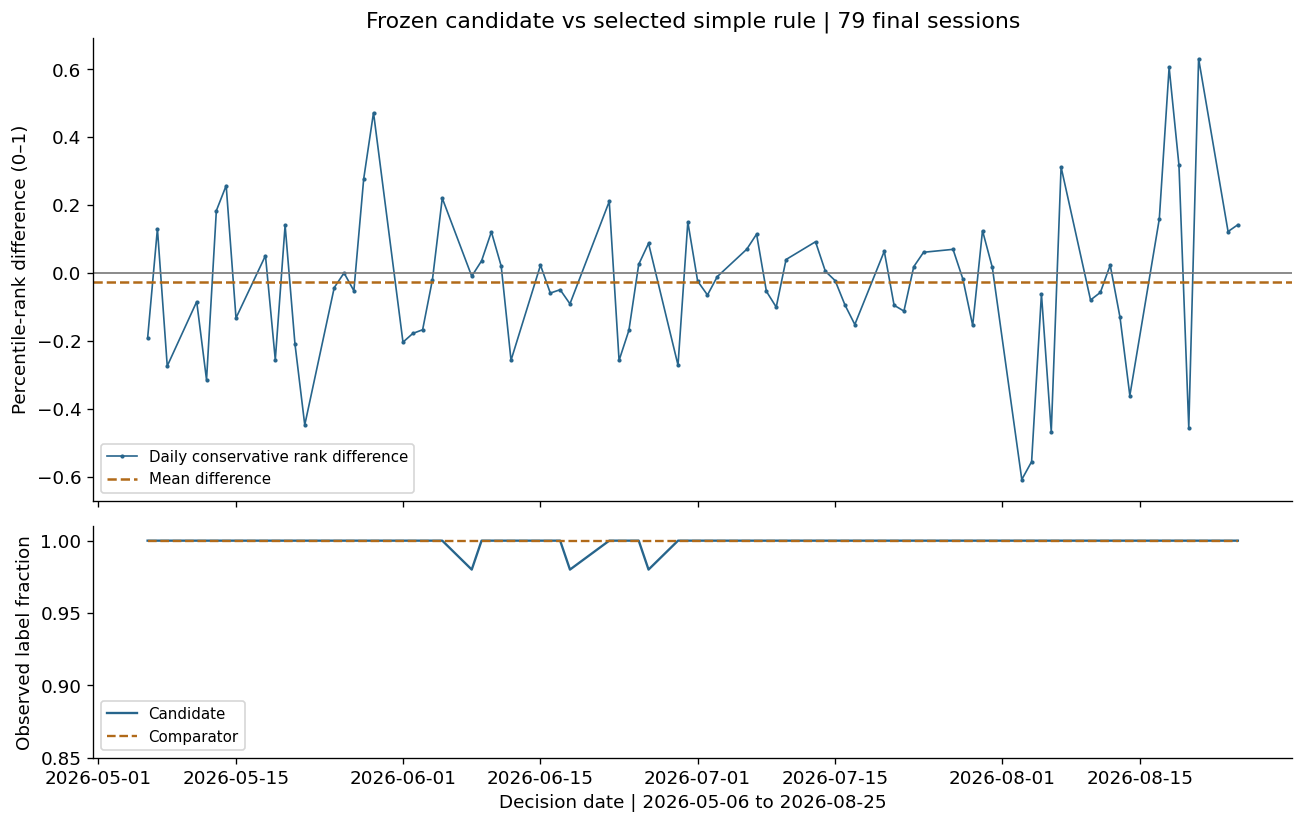

One-sided 95% lower confidence bound: -0.06739924409780203


In [5]:
plt.rcParams.update({'figure.figsize': (11, 6), 'font.size': 11, 'axes.spines.top': False, 'axes.spines.right': False, 'figure.dpi': 120})
final = pd.DataFrame(json.loads((evidence / 'final/daily-metrics.json').read_text()))
a = final.loc[final.method.eq(summary['candidate'])].set_index('trade_date')
b = final.loc[final.method.eq(summary['comparator'])].set_index('trade_date')
difference = a.top_rank_lower - b.top_rank_upper
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(11, 7), gridspec_kw={'height_ratios':[2,1]})
x = pd.to_datetime(difference.index)
axes[0].plot(x, difference, color='#27658c', linewidth=1, marker='.', markersize=3, label='Daily conservative rank difference')
axes[0].axhline(0, color='#777777', linewidth=1)
axes[0].axhline(summary['mean_conservative_rank_difference'], color='#b16a19', linestyle='--', label='Mean difference')
axes[0].set_ylabel('Percentile-rank difference (0–1)')
axes[0].set_title('Frozen candidate vs selected simple rule | 79 final sessions')
axes[0].legend(loc='lower left', fontsize=9)
axes[1].plot(x, a.label_count/a.selected_count, color='#27658c', label='Candidate', linewidth=1.4)
axes[1].plot(x, b.label_count/b.selected_count, color='#b16a19', linestyle='--', label='Comparator', linewidth=1.4)
axes[1].set_ylabel('Observed label fraction')
axes[1].set_ylim(0.85, 1.01)
axes[1].set_xlabel('Decision date | 2026-05-06 to 2026-08-25')
axes[1].legend(loc='lower left', fontsize=9)
fig.tight_layout()
fig.savefig(evidence / 'final-diagnostics.png')
plt.show()
print('One-sided 95% lower confidence bound:', summary['one_sided_95_lower_bound'])

## Takeaways

证据解释只写入 README 的 H01/H02 Conclusion。下列机器输出区分技术断言、统计门槛与实盘证据，避免把正常结束当成研究成功。

In [6]:
print('Boundary checks:', int(checks.get('passed', pd.Series(dtype=bool)).fillna(False).sum()), 'passed; plus existing daily API limitation reproduced')
print('Statistical pilot acceptance:', summary['statistical_pilot_passed'])
print('Actual historical real-time alignment:', summary['historical_real_time_alignment_verified'])
print('Net alpha:', summary['net_alpha_verified'])
print('Input unchanged:', json.loads((evidence / 'input-unchanged.json').read_text()))
for limitation in summary['limitations']:
    print('-', limitation)

Boundary checks: 8 passed; plus existing daily API limitation reproduced
Statistical pilot acceptance: False
Actual historical real-time alignment: False
Net alpha: False
Input unchanged: {'verified_files': 1094, 'all_content_unchanged': True}
- readiness timestamps are assumed
- historical files may have revisions
- ranking target is not money
- no intraday subscription or execution replay
- only 79 final dates and 40 selection dates; no long-term stability claim


<a id="research-boundaries"></a>

## 2026-09-19 共同研究边界与早期接口核对

以下保留研究开始时的共同方案和接口核对。当前目标与假设见 [README](README.md)，正式行为仍由 docs 中的 owner 定义。

**预测与行动。** 先固定信息、动作、结果、效用和比较基线，再选择学习器。参考价收益
或排名只是监督代理；可交易性还需入场/合法退出、订单规模、成本、风险及未成交处理。
I0 为分配前信息，Zq,w 为 topic 组合 q 在窗口 w 实际收到的信息；“值得观察”定义为
固定合法策略使用新增信息后的净效用增量：

```text
V(I0,q,w) = E[U(π1(I0,Zq,w),Y) - U(π0(I0),Y) | I0] - Cobs(q,w)
```

无新增 L2 的基线可等待、空仓或使用昨日信息；观察造成的等待损失也计入。订阅分配须
计持仓预留、topic 互补、组合相关性和冷启动；只有可加效用等近似成立时才能逐股排序。
固定套餐内的新增 topic 不等于新增账单，档位差价、闲置额度和机会成本分别计算。

**可见信息与时钟。** 保留输入版本/内容及取得时间、制品就绪时间、消息事件/接收时间、
源序号、订阅确认/断连区间、模型训练/加载时间、决策与订单时间，并满足：

```text
feature.input_available_at <= feature_ready_at <= decision_at
max(label_maturity, label_available_at) <= fit_start_at
fit_end_at <= model_ready_at <= decision_at
subscription effective at receipt; recv_ts <= snapshot cutoff
```

过去样本 X 须恢复其自身决策时的版本；当前修订值及文件 mtime 不能证明当时已知。
模型未按时就绪时，只有事前明确并在回放中一致执行的规则才允许沿用旧模型。
这些研究记录不直接扩展严格 `meta.json`；正式化须明确对应 owner。

**样本与当日特征。** 盘前 key 为 `(symbol, trade_date, allocation_ts)`，盘中为
`(symbol, trade_date, decision_ts, observation_spec)`；固定实验的 observation_spec
可保存为数据集参数。先定事前集合及列白名单，再独立连接标签；标签缺失、停牌、未成交
或无法退出不得反向重选 top-K，候选、分配、可推理、下单和可评价集合分别记录。
P 分区的 `asof_tminus1` 历史窗止于 P-1，不能再次盲目整体 lag。

当日全市场 rank 不能先计算再筛订阅池；池内排名也会改变语义，须按历史选池重放重训。
只读实际收到的消息并重新初始化 tick-rule/订单簿；晚订阅不能继承全日方向状态。
区分无成交、未订阅、丢失及状态未知，午休不计观察时长，后到消息不回写过去决策。
历史 L2 的现有覆盖与表达限制统一见 [H06 诊断](next_day_high.ipynb#h06-l2-coverage)。

**训练与验证。** 按完整日期分 train/select/final，标签须在拟合前成熟且可用；预处理只在
训练行拟合，与推理复用同一状态。保存每个合法模型及当时预测，不能用末期模型回测早期。
最终期可按冻结规则纳入已成熟过去标签，人工不能根据最终表现改配置。技术错误可同口径
修复；统计失败保留，已查看区间再用于开发时须另备独立确认信息。

历史 L2 初筛增量、固定池内当日 L2 决策增量、固定下游策略的资源分配增量分开比较。
观察价值标签须由训练区间内部的前向 π0/π1 产生同路径 ΔU，保留亏损、未成交和无行动
变化样本；不能用见过全历史的教师。全量历史模拟须有可信接收/初始化假设；只有被选中
对象的日志时，未选对象的反事实不可识别，不能对零支持区域直接作逆概率加权。

预测保留日期等权指标、覆盖及分组；行动另验净损益、回撤、暴露、成交、资金占用、费用
和延迟。日期配对区块重采样保留横截面/时间依赖，区间受小样本及分布变化限制。
T+1、涨跌停、手数、公司行动和终止持仓须进入执行账本；经济门槛待资金/风险约束明确。
影子运行还须验证相同已收快照的决策一致性与延迟。

**候选适配边界。** 以下仅为早期代码核对的必要结论，尚未接入正式入口：

| 边界 | 复用与待验证项 |
| --- | --- |
| Meta / 数据读取 | 保留既有身份与直接 upstream；时间及快照先存研究归档，见 [storage_layout](../../docs/data/storage_layout.md)、[access](../../docs/engineering/access.md) |
| 逐笔 / 分钟 / Feature | 复用归一化及聚合公式，在公式前裁剪已收事件、重置状态；受订阅约束的当日特征不能覆盖全市场 rank v1；order/market 须另定字段和状态契约 |
| dataset / preprocessing / inference | 日频两 key 不能验证盘中时间；推理独立于未来标签，白名单及 fitted transform 一致 |
| workflow / 模型制品 | 日期偏移不足以证明 timestamp 可用性；逐次保存 cutoff、ready、模型和预测。现有 fresh SGD 一次 `partial_fit` 不能当收敛基线，先在研究比较 Ridge/浅树 |
| replay / execution | 事件时间 minute cube 还需订阅、recv 和初始化限制；信号快照与未来执行路径分开，daily timing 不能证明盘中时序 |

既有编排 owner 见 [offline_workflow_contract](../../docs/offline_workflow_contract.md)。
研究输出不进入正式 registry、默认入口或生产状态；采用、代码发布和实盘启用分别确认。


<a id="h02-protocol"></a>

## H02 2026-09-19 冻结方案与验收

运行前完整记录：[冻结 README](/home/wsw/app/research-evidence/subscription-training-2026-09-19-po2l15iv/preregistered-README.md)。以下为便于阅读迁入的说明，原冻结记录不回写。

以下保留原实验口径；各归档的 `preregistered-README.md` 保存计算前完整方案。

| 项目 | 冻结值 |
| --- | --- |
| 输入 | 只读 `/home/wsw/app/data`，经正式 Meta 取得并复制；T=`2025-11-27..2026-08-25`，P 为前一 session；起点避开当时 `11-25` 分钟及 `11-24/25` H03 缺口，不自动跳日 |
| 样本 / 特征 | P 日 H03 股票池左连日频；D 为 base.yml 的七个日频量在该池独立百分位化，H 为 P 日 H03 固定32列加 lag 前缀；不读 T 日 L2 |
| 标签 | T 日既有 `y_rank_return`：T `[14:31,14:36)` 至 T+1 同窗参考收益排名，不重排 |
| 可用时间 | P 输入及当日到期标签假设 P 22:00 就绪；月首评价日08:00拟合、09:00前就绪并分配；没有历史日志证明 |
| 训练 / 预处理 | 最近60个完整且标签合法的 session，月首 fresh fit；rank/observed ratio 缺失均填0.5；日期等权权重归一到均值1，推理池不按标签删行 |
| 学习器 | Ridge(alpha=100, solver=cholesky)；HistGradientBoostingRegressor(max_iter=100, max_leaf_nodes=7, max_depth=3, min_samples_leaf=500, learning_rate=0.05, l2_regularization=10, max_bins=63, early_stopping=False, random_state=20260919) |
| 候选 / 对照 | Ridge/浅树 × D/D+H，单线程；规则为 P 成交额、已知5日动量及反向动量，另报随机解析期望但不参与最强规则选择 |
| 选池 / 选择 | K=50，同分按 symbol；满60合法日后至 `2026-04-29` 为选择期，按 top50 原标签缺失下界均值选候选及最强规则，同分按候选名；打开最终结果前落盘 |
| 最终期 | `2026-05-06..08-25`；`04-30` 标签到 `05-06` 晚才可用，不参与选择；最终期按原月度规则使用已成熟标签更新 |
| 主指标 | 日期等权 top50 排名的候选减规则差；未知标签按 [0,1] 给保守界：候选取0、对照取1；observed-only IC/loss 仅补充 |
| Acceptance | 至少50个最终日、两方 pooled 标签覆盖各≥98%、保守均值差≥0.02且5-session circular block bootstrap 单侧95%下界>0；seed=20260919，10,000次 |
| Stop | 四候选一次选择、最终只确认一次；不换赢家、移动门槛或将排名缺失界当作可成交收益 |


<a id="h02-evidence"></a>

## H02 2026-09-19 结果、失败与可恢复证据

**输入与选择。** 181目标日、937,799个事前股票日、936,127个已知标签；冻结1,094份
文件、336,648,777字节。选择期 `2026-03-04..04-29` 共40日，浅树 D+H 得分0.527944，
据此冻结与成交额规则（0.495720）比较；其余候选和逐日失败保留在归档。

**最终79日。** 模型/规则的可观察 top50 平均排名为0.474077/0.499570，覆盖为
99.9241%/100%，全横截面平均 Rank IC 为−0.029721/−0.049886。保守主差
**−0.025905**，单侧95%下界 **−0.067399**，未通过原门槛。5–8月各月 top50 均落后；
3/3,950个入选标签缺失不足以解释差异，整体 IC 较高也不能替代选池验收。

**可恢复证据。** 源码基线 `3f52cd232c7025d414e5ace547c69f8e3afd45c3`，计算为
[`validate_training.py`](validate_training.py)，Notebook 为 [`validation.ipynb`](validation.ipynb)。
初次与最终源码复跑目录分别为：

- `/home/wsw/app/research-evidence/subscription-training-2026-09-19-wpg08kc6/`
- `/home/wsw/app/research-evidence/subscription-training-2026-09-19-po2l15iv/`

归档含运行前方案、实际脚本、`source.tar`、`run.json`、完整输入/manifest、面板、参数、
模型/日程、冻结选择、逐日预测/名单/指标及 `final-summary.json`；至少保留至用户决定及
审查结束。Python 3.13.13、scikit-learn 1.8.0，环境 lock 随归档保存。
139份预测/模型等文件在两次执行中逐字节一致；79日名单和主指标独立重算一致，记录见
`independent-recomputation.json`。面板 SHA-256：
`11774b1f9e9e33c76ea2817b852febb41a15b3bb116cc7273c3cc193031c11c6`。
相关回归101 passed，Ruff/Mypy及 Notebook 从头执行通过；复跑不增加独立样本数。


<a id="h02-reproduce"></a>

## H02 复跑与证据检查

在2026-09-19归档所绑定的相同代码树及锁定环境下，可以直接使用已复制输入复跑，不需要生产凭证或
重新访问供应商。下面 H02 命令创建新的隔离证据目录，不覆盖已有结果：

```bash
cd /home/wsw/app/dev/trading
.venv/bin/python -B - <<'PY'
from pathlib import Path
import runpy

source = Path('/home/wsw/app/dev/trading')
driver = runpy.run_path(str(source / 'research/subscription-training/validate_training.py'))
evidence = driver['run_research'](
    source_root=source,
    storage_root=Path('/home/wsw/app/research-evidence/subscription-training-2026-09-19-po2l15iv/inputs'),
    evidence_parent=Path('/home/wsw/app/research-evidence'),
)
print(evidence)
PY
```

若当前代码树已变化，先在独立的本地 checkout 恢复记录中的基线 commit，再解开
`source.tar` 覆盖这个独立 checkout 的运行文件，并将归档的 `validate_training.py` 和
`preregistered-README.md` 放回该 checkout 的 `research/subscription-training/`；以它
作为 cwd 和 source_root，从保存的 `inputs/` 执行。不要覆盖正在工作的仓库或正式数据。
依赖按归档 `uv.lock` 恢复；Notebook 的 kernel 必须指向对应 Python 3.13 锁定环境。

检查 `input-manifest.json`、模型和预测内容、`fit-schedule.json`、`selection-frozen.json`
与 H02 的 `final-summary.json` 或 H04 的 `new-summary.json`。
逐次 wall time 可以变化，候选、输入、训练日期、预测和主指标
必须一致。所有复跑都是同一实验的恢复，不是新的样本外成功机会。
